In [2]:
import os
from pathlib import Path
from dotenv import load_dotenv

load_dotenv()

from typing import Annotated, TypedDict, List, Dict, Any, Optional, Literal
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph.message import add_messages
from pydantic import BaseModel, Field
from langchain_openai import OpenAIEmbeddings
from langchain_chroma import Chroma
from IPython.display import Image, display
from operator import add
import uuid

from db_con import get_user_hobbies

In [3]:
load_dotenv(override=True)

True

In [4]:
StressAnswer = Literal[
    "Never",
    "Almost Never",
    "Sometimes",
    "Fairly Often",
    "Very Often"
]

In [5]:
StressLevels = Literal[
    "Low Stress",
    "Moderate Stress", 
    "High Stress", 
    "No Stress"]

In [6]:
QUESTIONS = [
"In the last month, how often have you been upset because of something that happened unexpectedly?",
"In the last month, how often have you felt that you were unable to control important things in your life?"
]

In [7]:
class State(TypedDict):
    user_id: str
    messages: Annotated[List[Any], add_messages]
    topic_counter: int
    interact_with_user: bool
    temporal_answer: Optional[StressAnswer]
    actual_answers: Annotated[List[StressAnswer], add]
    stress_level: Optional[StressLevels]
    recommendations: Optional[str]
    complete_test:bool


In [8]:
class PsychiatristOutput(BaseModel):

    response: str = Field(
        description="Message to send to the user."
    )

    temporal_answer: Optional[StressAnswer] = Field(
        default=None,
        description="Final answer to the stress question if determined."
    )

    interact_with_user: bool = Field(
        description="Whether psychiatrist should continue interacting."
    )

In [9]:
psychiatrist_llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0
)

psychiatrist_llm_with_output = psychiatrist_llm.with_structured_output(PsychiatristOutput)

In [10]:
def psychiatrist(state: State) -> State:

    base_system_message = f"""
You are a professional psychiatrist conducting a stress evaluation interview.

Your goal is to determine the user's answer to the following question:

{QUESTIONS[state["topic_counter"]]}

Allowed answers:
Never
Almost Never
Sometimes
Fairly Often
Very Often

Instructions:
- Have a natural conversation with the user.
- Ask follow-up questions if the answer is unclear.
- Don't give suggested answers to the user.
- Only produce a temporal_answer if there is enough evidence from the conversation.
- If unsure, set temporal_answer to null and continue the conversation.

Rules:
If answer is clear:
    temporal_answer = one of allowed answers
    interact_with_user = false

If not answer is clear:
    temporal_answer = null
    interact_with_user = true
"""


    messages = (
        [SystemMessage(content=base_system_message)]
        + state["messages"]
    )

    psychiatrist_response = psychiatrist_llm_with_output.invoke(messages)

    return {
        "messages": [AIMessage(content=psychiatrist_response.response)],
        "temporal_answer": psychiatrist_response.temporal_answer,
        "interact_with_user": psychiatrist_response.interact_with_user
    }

In [11]:
def store_answer(state: State) -> State:

    return {
        "actual_answers": [state["temporal_answer"]],
        "topic_counter": state["topic_counter"] + 1,
        "temporal_answer": None
    }

In [12]:
score_map = {
    "Never":0,
    "Almost Never":1,
    "Sometimes":2,
    "Fairly Often":3,
    "Very Often":4
}

def calculate_stress(state: State):

    score = sum(score_map[a] for a in state["actual_answers"])

    if score <= 5:
        level = "No Stress"
    elif score <= 13:
        level = "Low Stress"
    elif score <= 26:
        level = "Moderate Stress"        
    else:
        level = "High Stress"

    return {"stress_level": level,
            "messages":[AIMessage(content=f"Your stress level is {level} with a score of {score}.")],
            "complete_test": True
            }

In [13]:
def retrieval_node(state: State):
    stress_level = state["stress_level"]
    from retrieval import fetch_context

    docs = fetch_context(f"recommendation for {stress_level}")
    context = "\n\n".join(doc.page_content for doc in docs)    

    return {
        "recommendations": context
    }

In [14]:
class RecommendationOutput(BaseModel):

    response: str = Field(
        description="Message to send to the user or recommendations based on stress level."
    )
    
    interact_with_user: bool = Field(
        description="Whether recommendations giver should continue interacting with user."
    )

In [15]:
recommendations_llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0
)

recommendations_llm_with_output = recommendations_llm.with_structured_output(RecommendationOutput)

In [ ]:
def recommendation(state: State) -> State:

    hobbies = get_user_hobbies(state["user_id"])
    hobbies_str = ", ".join(hobbies)

    base_system_message = f"""
    You are a supportive mental wellness assistant having a natural conversation with the user.

    Context:
    - User stress level determined from their responses: {state["stress_level"]}
    - Retrieved stress-management recommendations from the knowledge base: {state["recommendations"]}
    - User hobbies: {hobbies_str}

    Instructions:
    - Politely inform the user about the stress level(exactly given) determined from analyzing their responses.
    - Provide helpful recommendations to reduce stress using the retrieved recommendations.
    - If possible, relate the suggestions to the user's hobbies.
    - Answer any related questions the user asks and continue the conversation naturally.
    - Be supportive, empathetic, and keep responses clear and concise.
    - If the stress level is **"No Stress"**, politely inform the user that they currently do not show signs of stress and no specific recommendations are necessary, but encourage them to maintain healthy habits.
    """

    messages = (
        [SystemMessage(content=base_system_message)]
        + state["messages"]
    )

    recommendation_response = recommendations_llm_with_output.invoke(messages)

    return {
        "messages": [AIMessage(content=recommendation_response.response)],
        "interact_with_user": recommendation_response.interact_with_user
    }

In [17]:
def start_node_router(state: State):
    if state["complete_test"]:
        return "recommendation"
    else:
        return "psychiatrist"

In [18]:
def after_recommendation_router(state: State):

    if state["interact_with_user"]:
        return "END"

    return "END"

In [19]:
def psychiatrist_router(state: State):

    if state["interact_with_user"]:
        return "END"

    return "store_answer"

In [20]:
def after_store_router(state: State):

    if state.get("topic_counter", 0) >= len(QUESTIONS):
        return "calculate_stress"

    return "psychiatrist"

In [21]:
builder = StateGraph(State)

builder.add_node("psychiatrist", psychiatrist)
builder.add_node("store_answer", store_answer)
builder.add_node("calculate_stress", calculate_stress)
builder.add_node("retrieval", retrieval_node)
builder.add_node("recommendation", recommendation)

builder.add_conditional_edges(
    START,
    start_node_router,
    {"psychiatrist": "psychiatrist",
     "recommendation": "recommendation"}
)


builder.add_conditional_edges(
    "psychiatrist",
    psychiatrist_router,
    {
        "END": END,
        "store_answer": "store_answer"
    }
)

builder.add_conditional_edges(
    "store_answer",
    after_store_router,
    {
        "psychiatrist": "psychiatrist",
        "calculate_stress": "calculate_stress"
    }
)

builder.add_conditional_edges(
    "recommendation",
    after_recommendation_router,
    {
        "END": END,
        "END": END
    }
)

builder.add_edge("calculate_stress", "retrieval")
builder.add_edge("retrieval", "recommendation")
builder.add_edge("recommendation", END)
memory = MemorySaver()

graph = builder.compile(checkpointer=memory)

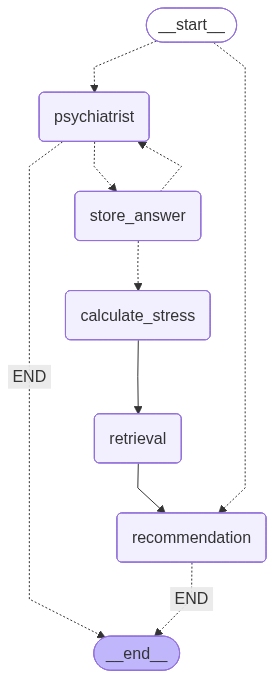

In [22]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [23]:
thread_config = {
    "configurable": {
        "thread_id": uuid.uuid4()
    }
}

In [24]:
result = graph.invoke(
    {
        "messages": [HumanMessage(content="hello iam hashan")],
        "user_id":"6RuThcCebLMWBdAUxSrhKZLEHei2",
        "topic_counter": 0,
        "actual_answers": [],
        "temporal_answer": None,
        "interact_with_user": True,
        "stress_level": None,
        "recommendations": None,
        "complete_test": False
    },
    config=thread_config
)
result

e:\MR.Mind_Projects\RP029-03\venv\Lib\site-packages\pydantic\main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=PsychiatristOutput(respon...interact_with_user=True), input_type=PsychiatristOutput])
  return self.__pydantic_serializer__.to_python(


{'user_id': '6RuThcCebLMWBdAUxSrhKZLEHei2',
 'messages': [HumanMessage(content='hello iam hashan', additional_kwargs={}, response_metadata={}, id='f11e2235-9ebe-4fb5-8628-b99a95635fb7'),
  AIMessage(content="Hello Hashan! It's nice to meet you. How are you feeling today?", additional_kwargs={}, response_metadata={}, id='7967926a-0972-4b1f-be9d-dbb4878a7cb8', tool_calls=[], invalid_tool_calls=[])],
 'topic_counter': 0,
 'interact_with_user': True,
 'temporal_answer': None,
 'actual_answers': [],
 'stress_level': None,
 'recommendations': None,
 'complete_test': False}

In [29]:
result = graph.invoke(
    {
        "messages": [HumanMessage(content="daly")]
    },
    config=thread_config
)
result

e:\MR.Mind_Projects\RP029-03\venv\Lib\site-packages\pydantic\main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=RecommendationOutput(resp...interact_with_user=True), input_type=RecommendationOutput])
  return self.__pydantic_serializer__.to_python(


{'user_id': '6RuThcCebLMWBdAUxSrhKZLEHei2',
 'messages': [HumanMessage(content='hello iam hashan', additional_kwargs={}, response_metadata={}, id='f11e2235-9ebe-4fb5-8628-b99a95635fb7'),
  AIMessage(content="Hello Hashan! It's nice to meet you. How are you feeling today?", additional_kwargs={}, response_metadata={}, id='7967926a-0972-4b1f-be9d-dbb4878a7cb8', tool_calls=[], invalid_tool_calls=[]),
  HumanMessage(content='nothing special', additional_kwargs={}, response_metadata={}, id='f4ee26dd-efb3-41a5-9553-1d0630e1e6ad'),
  AIMessage(content="That's completely okay. Sometimes we have days that feel pretty ordinary. I’d like to ask you a few questions to understand how you’ve been feeling lately, especially regarding stress. In the last month, how often have you been upset because of something that happened unexpectedly?", additional_kwargs={}, response_metadata={}, id='aea3deb8-320f-48d6-872f-868b375811ab', tool_calls=[], invalid_tool_calls=[]),
  HumanMessage(content='sometimes', ad